
      ANÁLISIS DE ENTROPÍA DE MENSAJES DE TRÁFICO DE RED

----------------------------------------------------------------------
Mensaje 1: LINK UP
----------------------------------------------------------------------
Distribución uniforme de símbolos:

Símbolo  Probabilidad
espacio      0.142857
      I      0.142857
      K      0.142857
      L      0.142857
      N      0.142857
      P      0.142857
      U      0.142857

Número de símbolos distintos: 7
Entropía: 2.8074 bits/símbolo


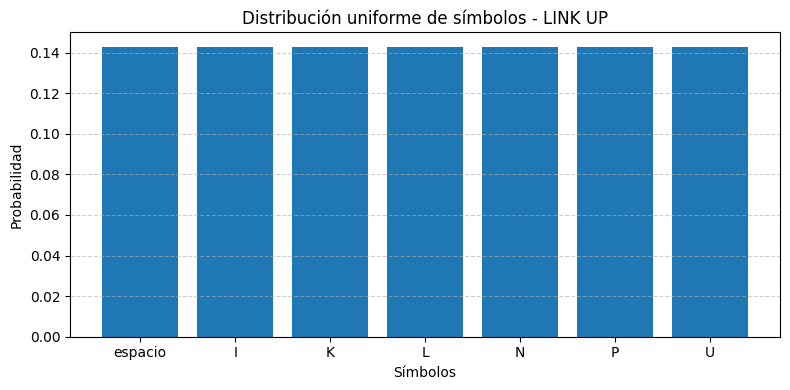


----------------------------------------------------------------------
Mensaje 2: SEND STATUS
----------------------------------------------------------------------
Distribución uniforme de símbolos:

Símbolo  Probabilidad
espacio         0.125
      A         0.125
      D         0.125
      E         0.125
      N         0.125
      S         0.125
      T         0.125
      U         0.125

Número de símbolos distintos: 8
Entropía: 3.0000 bits/símbolo


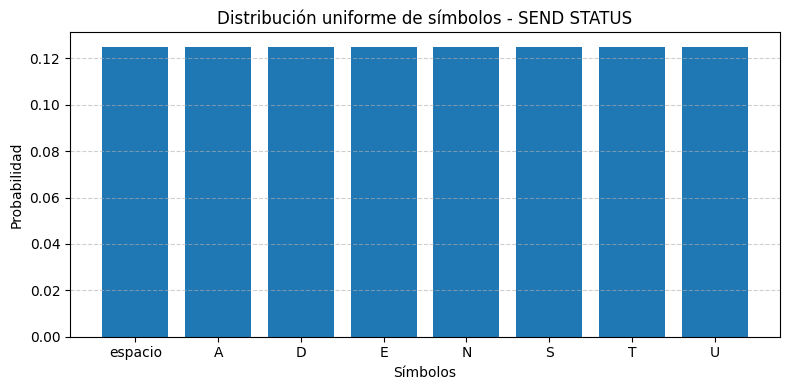


----------------------------------------------------------------------
Mensaje 3: PACKET LOSS
----------------------------------------------------------------------
Distribución uniforme de símbolos:

Símbolo  Probabilidad
espacio           0.1
      A           0.1
      C           0.1
      E           0.1
      K           0.1
      L           0.1
      O           0.1
      P           0.1
      S           0.1
      T           0.1

Número de símbolos distintos: 10
Entropía: 3.3219 bits/símbolo


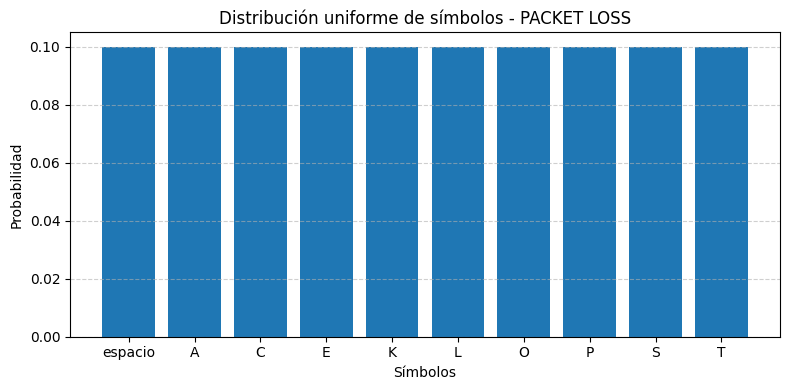


                         RESUMEN FINAL
    Mensaje  Número de símbolos  Entropía (bits/símbolo)
    LINK UP                   7                   2.8074
SEND STATUS                   8                   3.0000
PACKET LOSS                  10                   3.3219


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LECTURA DEL ARCHIVO EXCEL
# ============================================================
archivo = "dataFrame_D1B1.xlsx"
df = pd.read_excel(archivo, header=3, usecols="B:H")
df.columns = df.columns.str.strip()

# ============================================================
# OBTENER MENSAJES ÚNICOS
# ============================================================
mensajes = df["message"].dropna().astype(str).unique()

# ============================================================
# FUNCIÓN PARA CALCULAR ENTROPÍA UNIFORME
# ============================================================
def calcular_entropia_uniforme(mensaje):
    simbolos_unicos = sorted(set(mensaje))
    n = len(simbolos_unicos)
    probabilidades = [1 / n] * n
    entropia = -sum(p * np.log2(p) for p in probabilidades)
    simbolos_mostrados = ["espacio" if s == " " else s for s in simbolos_unicos]
    tabla = pd.DataFrame({
        "Símbolo": simbolos_mostrados,
        "Probabilidad": probabilidades
    })
    return tabla, entropia, n

# ============================================================
# TÍTULO GENERAL
# ============================================================
print("\n" + "=" * 70)
print("      ANÁLISIS DE ENTROPÍA DE MENSAJES DE TRÁFICO DE RED")
print("=" * 70)

resultados_generales = []

# ============================================================
# ANÁLISIS DE CADA MENSAJE
# ============================================================
for i, mensaje in enumerate(mensajes, start=1):
    tabla, entropia, n_simbolos = calcular_entropia_uniforme(mensaje)

    print("\n" + "-" * 70)
    print(f"Mensaje {i}: {mensaje}")
    print("-" * 70)
    print("Distribución uniforme de símbolos:\n")
    print(tabla.to_string(index=False))
    print(f"\nNúmero de símbolos distintos: {n_simbolos}")
    print(f"Entropía: {entropia:.4f} bits/símbolo")

    resultados_generales.append({
        "Mensaje": mensaje,
        "Número de símbolos": n_simbolos,
        "Entropía (bits/símbolo)": round(entropia, 4)
    })

    plt.figure(figsize=(8, 4))
    plt.bar(tabla["Símbolo"].astype(str), tabla["Probabilidad"])
    plt.xlabel("Símbolos")
    plt.ylabel("Probabilidad")
    plt.title(f"Distribución uniforme de símbolos - {mensaje}")
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# ============================================================
# RESUMEN FINAL
# ============================================================
df_resumen = pd.DataFrame(resultados_generales)

print("\n" + "=" * 70)
print("                         RESUMEN FINAL")
print("=" * 70)
print(df_resumen.to_string(index=False))
print("=" * 70)